# Exploratory Data Analysis — MovieLens Dataset
**Student:** Taibaz Pathan  
**University:** Frankfurt University of Applied Sciences  
**Week:** 2

Before building any models, I want to understand what the data actually looks like. How many ratings are there? Are users generous or harsh raters? Are most movies well-covered, or do a handful dominate? These questions matter because collaborative filtering relies entirely on the pattern of ratings — if the data is sparse or biased, the model will be too.

I'll work through the dataset systematically and note anything that might affect the modeling choices later.

## Setup

In [16]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.loader import load_all, dataset_summary

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

FIGURES_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    plt.savefig(path, bbox_inches='tight')
    print(f'saved → {path}')

## 1. Loading the Data

The dataset is the MovieLens ml-latest-small version from GroupLens. I'm using the loader I built in Week 1, which converts the unix timestamp to a readable datetime automatically.

In [17]:
DATA_DIR = os.path.abspath(os.path.join('..', 'data', 'raw', 'ml-latest-small'))

data    = load_all(DATA_DIR)
ratings = data['ratings']
movies  = data['movies']

dataset_summary(ratings, movies)

Dataset Summary
Ratings shape    : (100836, 4)
Movies shape     : (9742, 3)
Unique users     : 610
Unique movies    : 9724
Rating range     : 0.5 – 5.0
Rating mean      : 3.5016
Date range       : 1996-03-29 to 2018-09-24
Matrix sparsity  : 98.30%


In [18]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [19]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [20]:
# quick check for missing values — don't want any surprises later
print('Missing values in ratings:')
print(ratings.isnull().sum())
print()
print('Missing values in movies:')
print(movies.isnull().sum())

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64


No missing values — good. The dataset is clean out of the box, which is expected since GroupLens pre-processes it. Each user has rated at least 20 movies (that's a condition of the dataset).

## 2. Rating Distribution

First thing I want to see: what does the spread of ratings look like? Are people rating generously or critically?

saved → ../reports/figures/01_rating_distribution.png


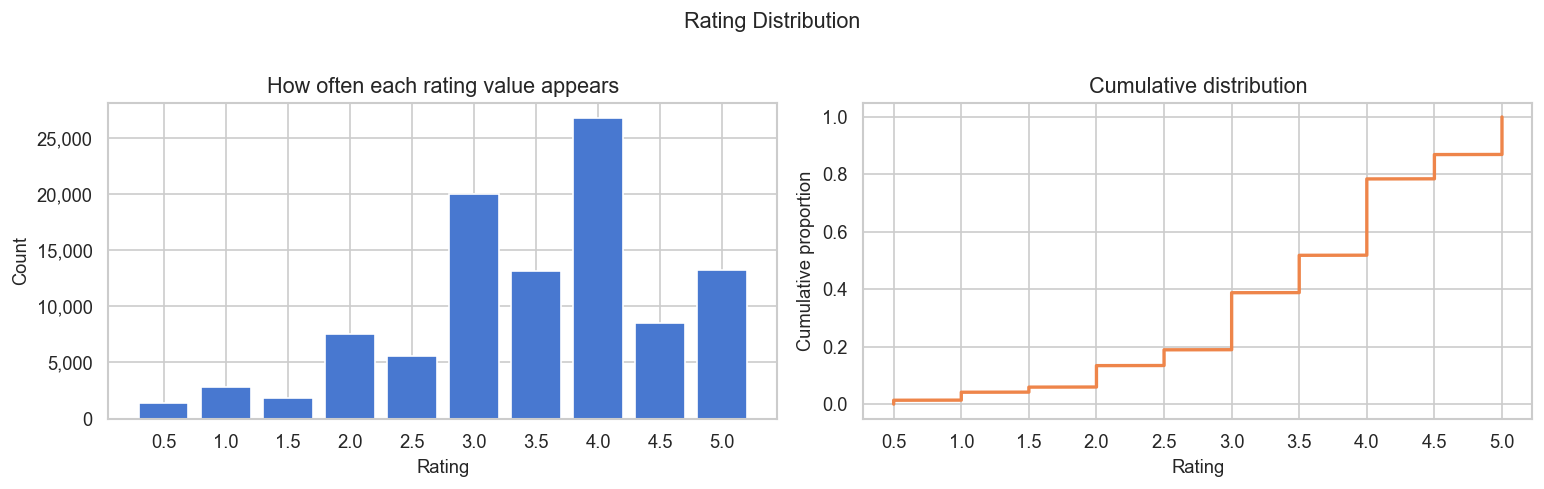

Mean   : 3.5016
Median : 3.5
Std    : 1.0425


In [21]:
rating_counts = ratings['rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(rating_counts.index, rating_counts.values, width=0.4,
            color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('How often each rating value appears')
axes[0].set_xticks(rating_counts.index)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

sorted_r = np.sort(ratings['rating'].values)
cdf = np.arange(1, len(sorted_r) + 1) / len(sorted_r)
axes[1].plot(sorted_r, cdf, color=sns.color_palette('muted')[1], linewidth=2)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cumulative proportion')
axes[1].set_title('Cumulative distribution')
axes[1].set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

plt.suptitle('Rating Distribution', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('01_rating_distribution')
plt.show()

print(f'Mean   : {ratings["rating"].mean():.4f}')
print(f'Median : {ratings["rating"].median()}')
print(f'Std    : {ratings["rating"].std():.4f}')

The mean rating is around 3.5, which is above the midpoint of 2.75. This tells me users tend to rate movies they already chose to watch (and probably liked), creating a positive bias. Half-star ratings (0.5, 1.5, 2.5 etc.) are used much less than whole-star ratings — most people just go for round numbers.

This bias matters for UBCF. If I compute similarity using raw ratings, users who consistently rate high will appear similar even if their tastes differ. Mean-centring (subtracting each user's average) should fix this.

## 3. How Active Are Users?

Some users rate hundreds of movies, others just the minimum 20. This affects how reliable their similarity scores will be.

saved → ../reports/figures/02_ratings_per_user.png


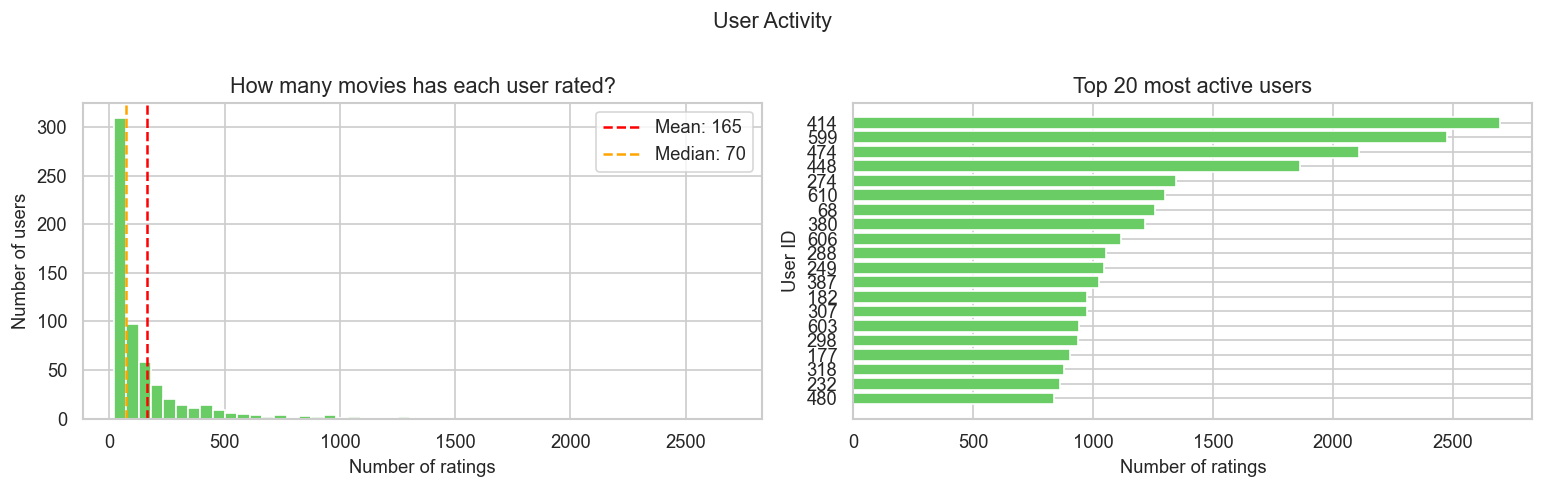

Min  : 20
Max  : 2698
Mean : 165.3
Median: 70


In [22]:
ratings_per_user = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_user.values, bins=50,
             color=sns.color_palette('muted')[2], edgecolor='white')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')
axes[0].set_title('How many movies has each user rated?')
axes[0].axvline(ratings_per_user.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {ratings_per_user.mean():.0f}')
axes[0].axvline(ratings_per_user.median(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Median: {ratings_per_user.median():.0f}')
axes[0].legend()

top20_users = ratings_per_user.head(20)
axes[1].barh(top20_users.index.astype(str), top20_users.values,
             color=sns.color_palette('muted')[2])
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('User ID')
axes[1].set_title('Top 20 most active users')

plt.suptitle('User Activity', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('02_ratings_per_user')
plt.show()

print(f'Min  : {ratings_per_user.min()}')
print(f'Max  : {ratings_per_user.max()}')
print(f'Mean : {ratings_per_user.mean():.1f}')
print(f'Median: {ratings_per_user.median():.0f}')

The distribution is heavily skewed — a small number of users are extremely active (one user has over 2,000 ratings) while most users cluster near the minimum. The mean (165) is much higher than the median (68), which confirms this skew.

For UBCF, users with very few ratings will have poor similarity scores because there aren't enough co-rated movies to compute a reliable Pearson correlation. I'll need to keep the `min_support` threshold in mind during Week 5.

## 4. How Many Ratings Do Movies Get?

This is the classic long-tail problem in recommendation systems — most movies are rarely rated.

saved → ../reports/figures/03_ratings_per_movie.png


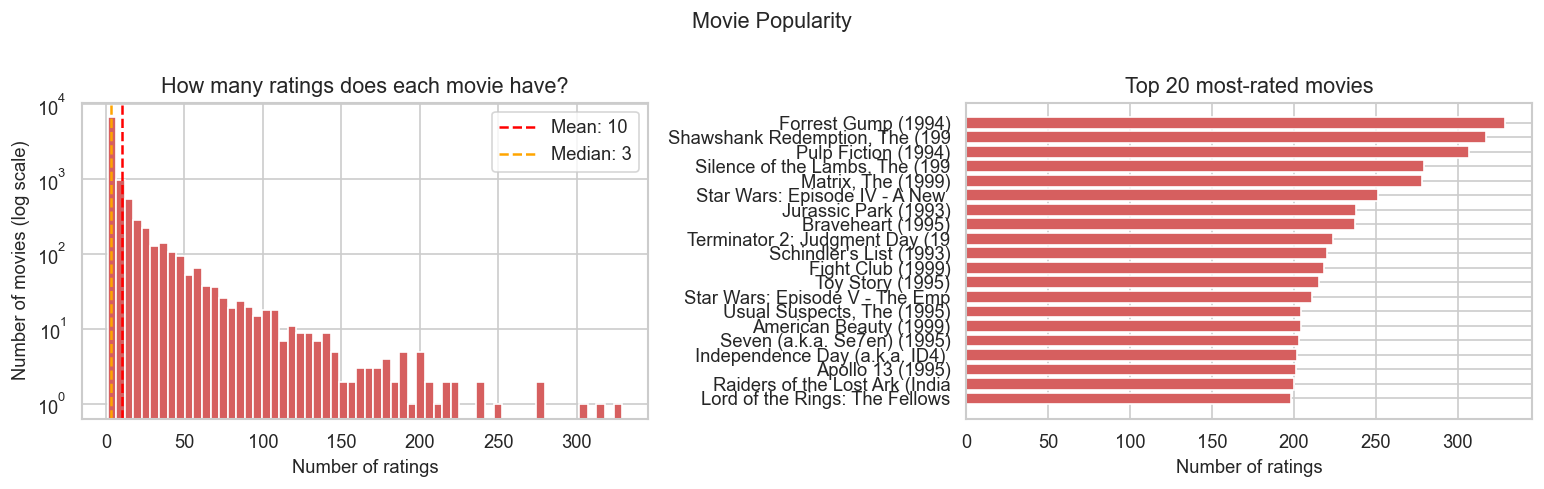

Min ratings per movie  : 1
Max ratings per movie  : 329
Mean                   : 10.4
Median                 : 3
Movies with < 5 ratings : 6074
Movies with < 20 ratings: 8427


In [23]:
ratings_per_movie = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ratings_per_movie.values, bins=60,
             color=sns.color_palette('muted')[3], edgecolor='white')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of movies (log scale)')
axes[0].set_title('How many ratings does each movie have?')
axes[0].set_yscale('log')
axes[0].axvline(ratings_per_movie.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {ratings_per_movie.mean():.0f}')
axes[0].axvline(ratings_per_movie.median(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Median: {ratings_per_movie.median():.0f}')
axes[0].legend()

top20_movies = ratings_per_movie.head(20)
top20_titles = movies.set_index('movieId').loc[top20_movies.index, 'title'].str.slice(0, 30)
axes[1].barh(top20_titles.values, top20_movies.values,
             color=sns.color_palette('muted')[3])
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of ratings')
axes[1].set_title('Top 20 most-rated movies')

plt.suptitle('Movie Popularity', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('03_ratings_per_movie')
plt.show()

print(f'Min ratings per movie  : {ratings_per_movie.min()}')
print(f'Max ratings per movie  : {ratings_per_movie.max()}')
print(f'Mean                   : {ratings_per_movie.mean():.1f}')
print(f'Median                 : {ratings_per_movie.median():.0f}')
print(f'Movies with < 5 ratings : {(ratings_per_movie < 5).sum()}')
print(f'Movies with < 20 ratings: {(ratings_per_movie < 20).sum()}')

The long tail is very clear here. Forrest Gump, Shawshank Redemption, Pulp Fiction etc. dominate the top. Most movies have only a handful of ratings — the median is surprisingly low. Movies with fewer than 20 ratings will be hard to recommend reliably because there are too few users to compute meaningful item similarities. I'll filter these out when building the recommendation pipeline.

## 5. Matrix Sparsity

If every user rated every movie, the user-item matrix would be fully dense. In practice, it's almost entirely empty.

Users          : 610
Movies         : 9724
Ratings        : 100,836
Possible pairs : 5,931,640
Sparsity       : 98.30%
saved → ../reports/figures/04_sparsity.png


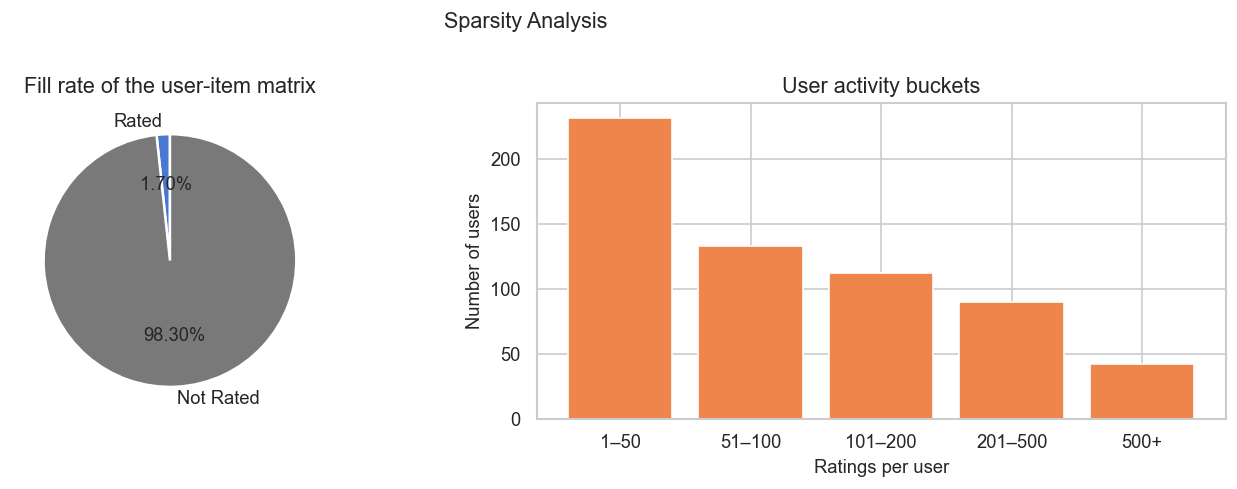

In [24]:
n_users   = ratings['userId'].nunique()
n_movies  = ratings['movieId'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_movies)

print(f'Users          : {n_users}')
print(f'Movies         : {n_movies}')
print(f'Ratings        : {n_ratings:,}')
print(f'Possible pairs : {n_users * n_movies:,}')
print(f'Sparsity       : {sparsity * 100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [n_ratings, n_users * n_movies - n_ratings],
    labels=['Rated', 'Not Rated'],
    colors=[sns.color_palette('muted')[0], sns.color_palette('muted')[7]],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Fill rate of the user-item matrix')

bins   = [0, 50, 100, 200, 500, 2500]
labels_bin = ['1–50', '51–100', '101–200', '201–500', '500+']
user_buckets = pd.cut(ratings_per_user, bins=bins, labels=labels_bin).value_counts().sort_index()
axes[1].bar(user_buckets.index, user_buckets.values,
            color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_xlabel('Ratings per user')
axes[1].set_ylabel('Number of users')
axes[1].set_title('User activity buckets')

plt.suptitle('Sparsity Analysis', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('04_sparsity')
plt.show()

98.3% sparse. Only 1 in 60 user-movie combinations has a rating. This is actually typical for real-world recommendation datasets — Netflix reportedly had 99%+ sparsity. The consequence is that two random users are unlikely to share many co-rated movies, which makes computing Pearson correlation unstable. This is exactly why I'll need a `min_support` threshold: only trust similarity scores based on at least N shared movies.

## 6. Average Rating per Movie

Are popular movies also the highest rated? Or does quality and popularity not always align?

saved → ../reports/figures/05_movie_avg_rating.png


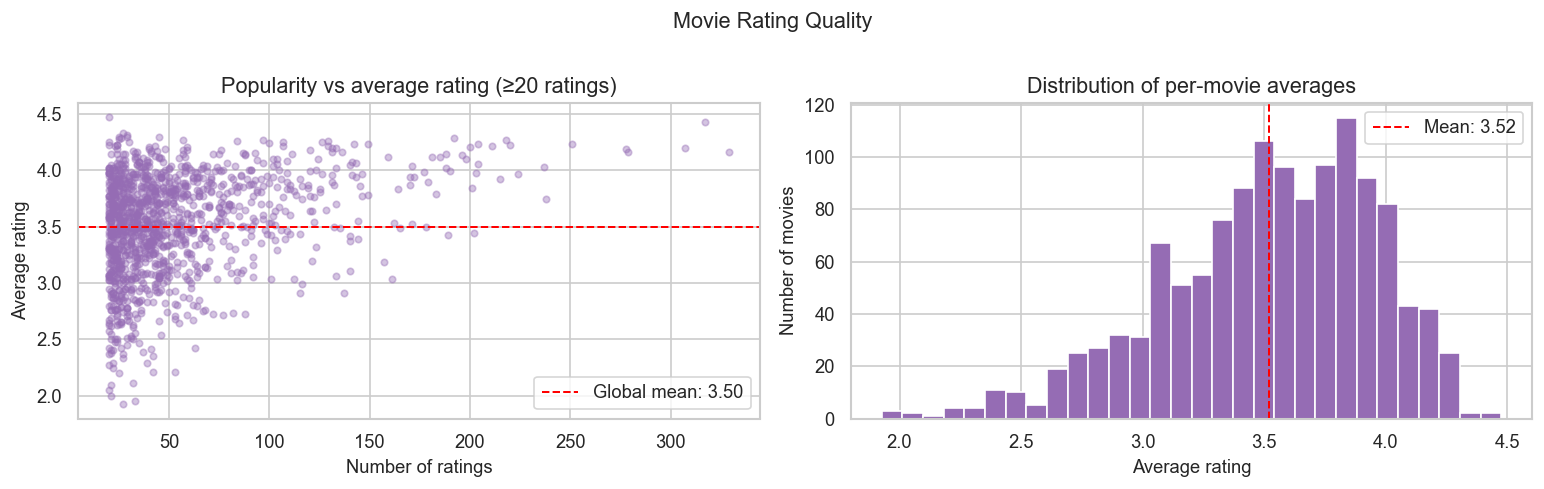

In [25]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['count', 'mean']).reset_index()
movie_stats.columns = ['movieId', 'num_ratings', 'avg_rating']

# only look at movies with enough ratings to be meaningful
movie_stats = movie_stats[movie_stats['num_ratings'] >= 20]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(movie_stats['num_ratings'], movie_stats['avg_rating'],
                alpha=0.4, s=15, color=sns.color_palette('muted')[4])
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Average rating')
axes[0].set_title('Popularity vs average rating (≥20 ratings)')
axes[0].axhline(ratings['rating'].mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'Global mean: {ratings["rating"].mean():.2f}')
axes[0].legend()

axes[1].hist(movie_stats['avg_rating'], bins=30,
             color=sns.color_palette('muted')[4], edgecolor='white')
axes[1].set_xlabel('Average rating')
axes[1].set_ylabel('Number of movies')
axes[1].set_title('Distribution of per-movie averages')
axes[1].axvline(movie_stats['avg_rating'].mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'Mean: {movie_stats["avg_rating"].mean():.2f}')
axes[1].legend()

plt.suptitle('Movie Rating Quality', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('05_movie_avg_rating')
plt.show()

There's a slight tendency for heavily-rated movies to cluster around 3.5–4.0, but no strong correlation between popularity and quality. Some niche films with fewer ratings have very high averages — though these could just be lucky (small sample effect). Most movies sit between 3.0 and 4.5.

## 7. Genre Breakdown

What kinds of movies are in the dataset? This won't directly affect the CF models (they don't use content), but it's good background for the report.

saved → ../reports/figures/06_genre_distribution.png


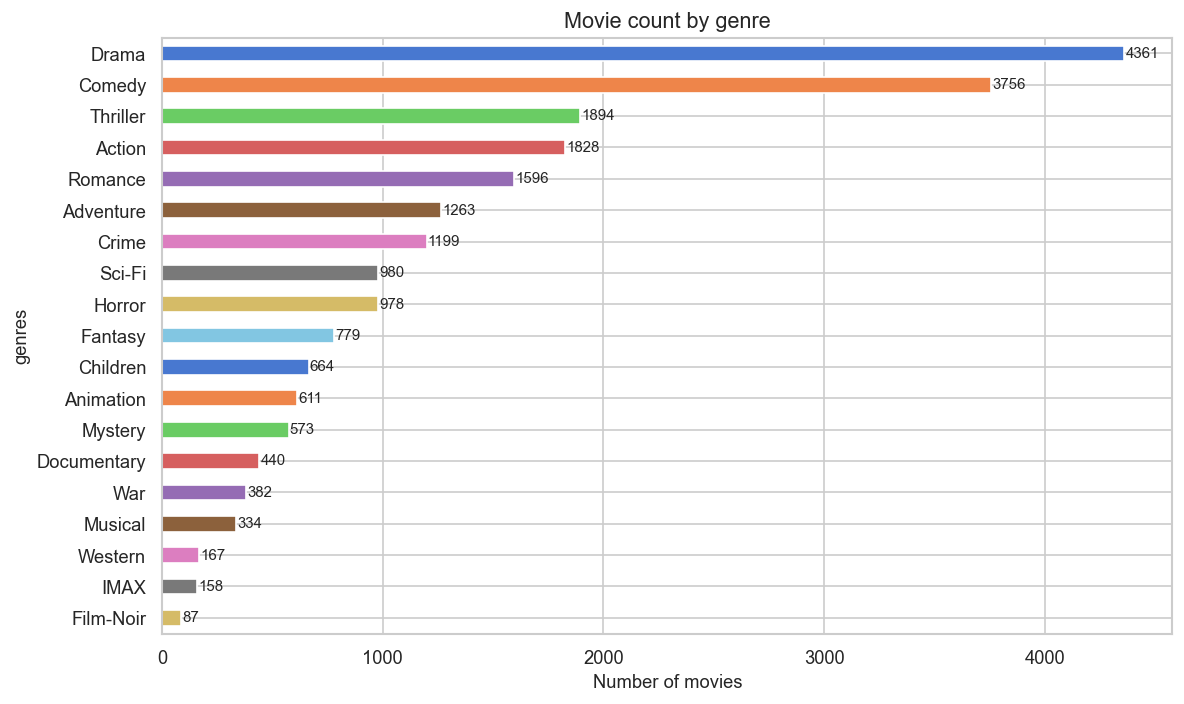

Unique genres : 19
Most common   : Drama (4361 movies)


In [26]:
genre_series = movies['genres'].str.split('|').explode()
genre_counts = genre_series[genre_series != '(no genres listed)'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.plot(kind='barh', ax=ax,
                  color=sns.color_palette('muted', len(genre_counts)),
                  edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Number of movies')
ax.set_title('Movie count by genre')
for i, v in enumerate(genre_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
save_fig('06_genre_distribution')
plt.show()

print(f'Unique genres : {len(genre_counts)}')
print(f'Most common   : {genre_counts.index[0]} ({genre_counts.iloc[0]} movies)')

Drama and Comedy dominate — which makes sense as they're the broadest categories. The dataset covers 20 genres in total. Worth noting that many movies have multiple genres, so these counts aren't mutually exclusive.

## 8. Ratings Over Time

I'm curious whether rating activity and average scores changed over the years.

saved → ../reports/figures/07_ratings_over_time.png


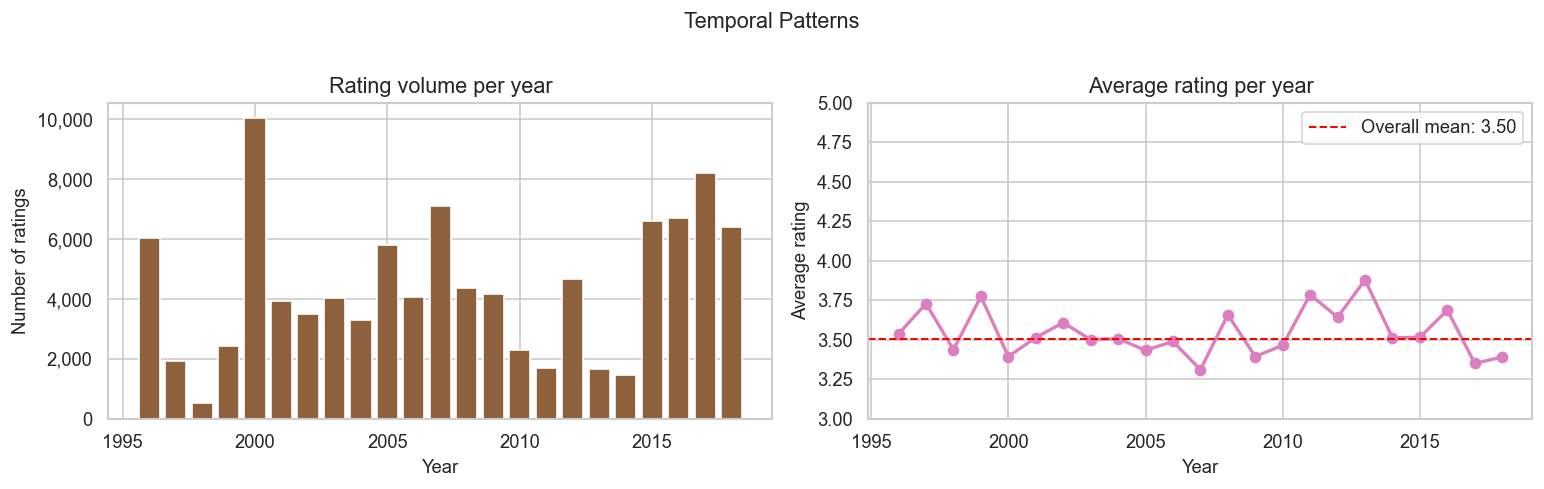

In [27]:
ratings['year'] = ratings['timestamp'].dt.year

yearly = ratings.groupby('year').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(yearly['year'], yearly['num_ratings'],
            color=sns.color_palette('muted')[5], edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of ratings')
axes[0].set_title('Rating volume per year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].plot(yearly['year'], yearly['avg_rating'],
             marker='o', color=sns.color_palette('muted')[6], linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average rating')
axes[1].set_title('Average rating per year')
axes[1].set_ylim(3.0, 5.0)
axes[1].axhline(ratings['rating'].mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'Overall mean: {ratings["rating"].mean():.2f}')
axes[1].legend()

plt.suptitle('Temporal Patterns', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('07_ratings_over_time')
plt.show()

Rating activity peaked in the early 2000s and has been more spread out since. The average rating per year is fairly stable around 3.5, with some fluctuation in years with very few ratings (early/late years). The dataset spans 1996 to 2018 — 22 years of movie watching habits.

## 9. Key Takeaways

After going through the data, here is what I think will matter most when building the models:

- **Positive rating bias** — users rate above the midpoint on average. Mean-centring per user will be important in UBCF to separate genuine taste similarity from scale differences.
- **98.3% sparsity** — most user pairs share very few co-rated movies. A `min_support` parameter (minimum co-rated items before computing similarity) is essential, otherwise Pearson correlation becomes unreliable.
- **Long-tail movie distribution** — many movies have fewer than 20 ratings. These should be filtered out during evaluation; there is not enough data to compute meaningful similarity for them.
- **Unequal user activity** — a handful of power users dominate. Median user rated only ~68 movies, which is relatively sparse. IBCF might handle this better than UBCF since it focuses on item similarity rather than finding similar users.
- **No missing values** — the data is clean and ready for preprocessing in Week 3.

In [28]:
print('All figures saved to reports/figures/')
print('Week 2 EDA complete.')

All figures saved to reports/figures/
Week 2 EDA complete.
